In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

## Q5.制作透明图像
### 输入图像，用鼠标选择选择前景目标像素（目标边缘不需要很精细）。
### 将原图中除了前景目标之外的其它所有像素设置为透明。
### 保存只包含前景目标的透明图像。

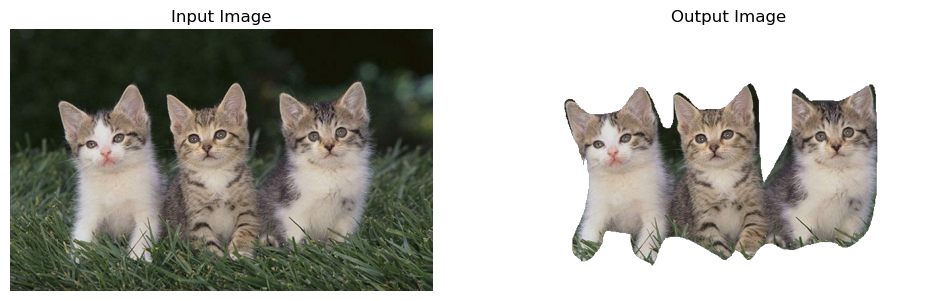

In [2]:
# 全局变量
drawing = False
points = []


# 用鼠标框选前景
# 按enter出现后景透明的图像
# 按esc退出全部

# 鼠标选择
def draw_polygon(event, x, y, flags, param):
    global drawing, points

    if event == cv.EVENT_LBUTTONDOWN:
        drawing = True
        points = [(x, y)]
    elif event == cv.EVENT_MOUSEMOVE:
        if drawing:
            points.append((x, y))
    elif event == cv.EVENT_LBUTTONUP:
        drawing = False
        points.append((x, y))


def show_images(input_image_path, output_image_path):
    # 读取
    input_img = cv.imread(input_image_path, cv.IMREAD_UNCHANGED)
    output_img = cv.imread(output_image_path, cv.IMREAD_UNCHANGED)

    # BGR(A) to RGB
    input_img_rgb = cv.cvtColor(input_img, cv.COLOR_BGRA2RGBA) if input_img.shape[2] == 4 else cv.cvtColor(input_img,
                                                                                                           cv.COLOR_BGR2RGB)
    output_img_rgb = cv.cvtColor(output_img, cv.COLOR_BGRA2RGBA)

    # 创建并显示
    plt.figure(figsize=(12, 6))

    # 输入
    plt.subplot(1, 2, 1)
    plt.imshow(input_img_rgb)
    plt.title('Input Image')
    plt.axis('off')

    # 输出
    plt.subplot(1, 2, 2)
    plt.imshow(output_img_rgb)
    plt.title('Output Image')
    plt.axis('off')

    plt.show()


# 读取图像
image = cv.imread('Q5_input.jpg', cv.IMREAD_COLOR)
if image is None:
    raise ValueError("图像加载失败")

# 创建透明背景
# 当Alpha为0时，像素完全透明，当Alpha为255时，像素完全不透明
height, width = image.shape[:2]
# 透明画布 四通道
overlay = np.zeros((height, width, 4), dtype=np.uint8)

# 获取前景区域
cv.namedWindow('Image')
cv.setMouseCallback('Image', draw_polygon)

while True:
    temp_image = image.copy()
    if points:
        for i in range(len(points) - 1):
            # 绘制线条
            cv.line(temp_image, points[i], points[i + 1], (0, 255, 0), 2)
        # 绘制前景区域的多边形轮廓
        cv.polylines(temp_image, [np.array(points)], isClosed=True, color=(0, 255, 0), thickness=2)

    cv.imshow('Image', temp_image)
    key = cv.waitKey(1) & 0xFF

    if key == 13:  # 按enter确认选择
        break

# 创建掩膜
mask = np.zeros((height, width), dtype=np.uint8)
# 绘制掩膜
# 多边形内部区域为 255 白色 ，之外为 0 黑色
if points:
    cv.fillPoly(mask, [np.array(points)], 255)

# 生成透明图像
for y in range(height):
    for x in range(width):
        if mask[y, x] == 255:
            overlay[y, x, :3] = image[y, x]
            # alpha 为 255（完全不透明）
            overlay[y, x, 3] = 255
            # 其余为 0（完全透明）

# 展示透明图像
while True:
    cv.imshow('modified_img', overlay)
    k = cv.waitKey(1) & 0xFF
    if k == 27:  # 退出窗口键
        break

# 保存透明图像
cv.imwrite('Q5_output.png', overlay)

cv.destroyAllWindows()
show_images('Q5_input.jpg', 'Q5_output.png')

## Q6.在图像中添加一个物体
### 输入一张图像和另一个待插入的包含某个物体的透明图像。
### 将待插入图像插入鼠标所在的位置。
### 移动鼠标，该图像跟着移动。
### 设置一个滚动条，拖动该滚动条，所插入物体相应的放大或缩小。
### 按Enter键确认，保存合成的图像，退出。

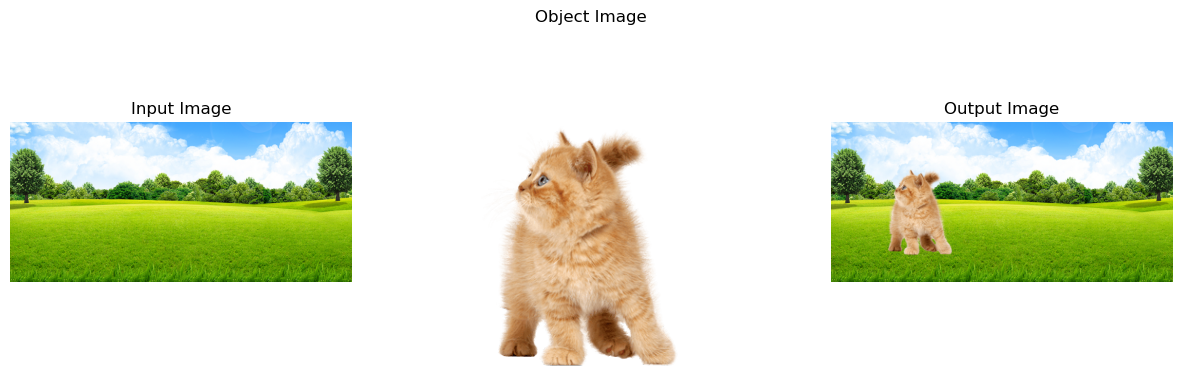

In [3]:
# 移动鼠标，图像跟随移动（略有延时）
# 拖动滑块，改变图像大小
# 左击鼠标后，图像固定不动
# 按enter，保存并退出

# 初始化全局变量
global img, object_img, temp_img, scale, start_point, fixed
# 初始大小
scale = 0.5
# 初始位置
start_point = (0, 0)
# 标记图像是否固定
fixed = False


# 鼠标回调函数，实时更新插入图像的位置，且位置在点击鼠标左键之后不变
def mouse_callback(event, x, y, flags, param):
    global start_point, fixed

    if event == cv.EVENT_LBUTTONDOWN:  # 左击
        fixed = True  # 固定
    elif not fixed:  # 跟随鼠标
        start_point = (x, y)
        update_image()


# 更新并显示
def update_image():
    global img, object_img, temp_img, start_point, scale
    temp_img = img.copy()

    # 缩放
    scaled_object = cv.resize(object_img, None, fx=scale, fy=scale, interpolation=cv.INTER_LINEAR)
    # 获取缩放后尺寸
    obj_h, obj_w = scaled_object.shape[:2]

    # 计算放置图像的位置----以鼠标为中心
    x = min(max(0, start_point[0] - obj_w // 2), temp_img.shape[1] - obj_w)
    y = min(max(0, start_point[1] - obj_h // 2), temp_img.shape[0] - obj_h)

    # 插入
    for i in range(obj_h):
        for j in range(obj_w):
            alpha = scaled_object[i, j, 3] / 255.0
            # 部分叠加
            temp_img[y + i, x + j] = alpha * scaled_object[i, j, :3] + (1 - alpha) * temp_img[y + i, x + j]

    # 显示图像
    cv.imshow("Image", temp_img)


# 滚动条回调函数
def on_trackbar(val):
    global scale
    # 百分比
    scale = val / 100.0
    update_image()


def show_images(input_image_path, object_image_path, output_image_path):
    # 读取图像
    input_img = cv.imread(input_image_path, cv.IMREAD_UNCHANGED)
    object_img = cv.imread(object_image_path, cv.IMREAD_UNCHANGED)
    output_img = cv.imread(output_image_path, cv.IMREAD_UNCHANGED)

    input_img_rgb = cv.cvtColor(input_img, cv.COLOR_BGRA2RGBA) if input_img.shape[2] == 4 else cv.cvtColor(input_img,
                                                                                                           cv.COLOR_BGR2RGB)
    object_img_rgb = cv.cvtColor(object_img, cv.COLOR_BGRA2RGBA) if object_img.shape[2] == 4 else cv.cvtColor(
        object_img, cv.COLOR_BGR2RGB)
    output_img_rgb = cv.cvtColor(output_img, cv.COLOR_BGRA2RGBA) if output_img.shape[2] == 4 else cv.cvtColor(
        output_img, cv.COLOR_BGR2RGB)

    # 显示被插入图像
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title("Input Image")
    plt.imshow(input_img_rgb)
    plt.axis('off')

    # 显示待插入图像
    plt.subplot(1, 3, 2)
    plt.title("Object Image")
    plt.imshow(object_img_rgb)
    plt.axis('off')

    # 显示插入后的图像
    plt.subplot(1, 3, 3)
    plt.title("Output Image")
    plt.imshow(output_img_rgb)
    plt.axis('off')

    # 显示所有图像
    plt.show()


def main():
    global img, object_img, temp_img, scale, start_point

    # 读取
    img = cv.imread('Q6_input.jpg', cv.IMREAD_UNCHANGED)
    object_img = cv.imread('Q6_object.png', cv.IMREAD_UNCHANGED)

    # 设置回调函数
    cv.namedWindow("Image")
    cv.setMouseCallback("Image", mouse_callback)

    # 创建滚动条
    cv.createTrackbar('Scale', 'Image', 50, 100, on_trackbar)

    while True:
        if not fixed:
            update_image()
        key = cv.waitKey(1) & 0xFF
        if key == 13:  # Enter 键
            break

    # 保存插入后图像
    cv.imwrite('Q6_output.png', temp_img)
    cv.destroyAllWindows()


if __name__ == "__main__":
    main()
    show_images('Q6_input.jpg', 'Q6_object.png', 'Q6_output.png')
    

## Q7.在图像中隐藏信息
### 准备载体图像和秘密图像，两图像的大小一样，都为彩色图像
### 用LSB等方法将秘密图像隐藏到载体图像中
### 从加密的载体图像中提取秘密图像
### 采用多种方法实现，比较不同方法的结果，尽量减少恢复的秘密图像的失真程度
### 显示并比较加密的载体图像、原秘密图像和恢复的秘密图像

## Q7-1 LSB方法

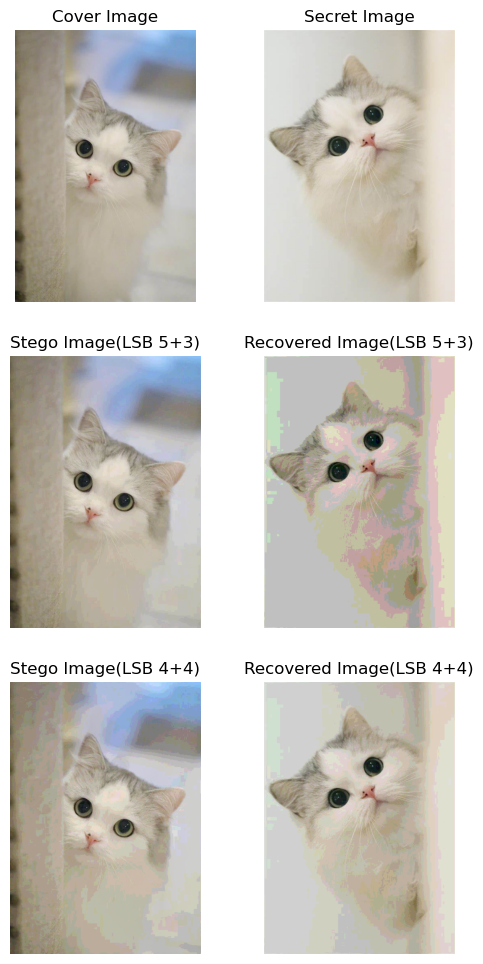

In [4]:
def LSB_hide_image_5_3(cover_image_path, secret_image_path, output_image_path):
    # 读取载体图像和秘密图像,统一大小
    cover_img = cv.imread(cover_image_path)
    secret_img = cv.imread(secret_image_path)
    x, y, z = secret_img.shape
    cover_img = cover_img[:x, :y, :]

    # 要还原成彩色，用cover_img的低3位存secret_img的高3位
    # 保留 cover_img 的高5位
    t248 = np.ones(secret_img.shape, dtype=np.uint8) * 248
    H5 = cv.bitwise_and(cover_img, t248)
    # 保留 secret_img 的高3位
    t224 = np.ones(secret_img.shape, dtype=np.uint8) * 224
    H3 = cv.bitwise_and(secret_img, t224)
    # 转成低3位
    L3 = H3 >> 5
    stego_image = cv.bitwise_or(H5, L3)

    # save
    cv.imwrite(output_image_path, stego_image)


def LSB_hide_image_4_4(cover_image_path, secret_image_path, output_image_path):
    # 读取载体图像和秘密图像,统一大小
    cover_img = cv.imread(cover_image_path)
    secret_img = cv.imread(secret_image_path)
    x, y, z = secret_img.shape
    cover_img = cover_img[:x, :y, :]

    # 用cover_img的低4位存secret_img的高4位
    t240 = np.ones(secret_img.shape, dtype=np.uint8) * 240
    H4 = cv.bitwise_and(cover_img, t240)
    H4_s = cv.bitwise_and(secret_img, t240)
    L4 = H4_s >> 4
    stego_image = cv.bitwise_or(H4, L4)

    # save
    cv.imwrite(output_image_path, stego_image)


def LSB_extract_image_5_3(stego_image_path, output_secret_image_path):
    # 读取加密图像
    stego_img = cv.imread(stego_image_path)

    # LSB
    t7 = np.ones(stego_img.shape, dtype=np.uint8) * 7
    # 读取 secret_img 的高3位 (stego_img的低3位)
    H3 = cv.bitwise_and(stego_img, t7)
    secret_img = H3 << 5

    # save
    cv.imwrite(output_secret_image_path, secret_img)


def LSB_extract_image_4_4(stego_image_path, output_secret_image_path):
    # 读取加密图像
    stego_img = cv.imread(stego_image_path)

    # LSB
    t15 = np.ones(stego_img.shape, dtype=np.uint8) * 15
    H4 = cv.bitwise_and(stego_img, t15)
    secret_img = H4 << 4

    # save
    cv.imwrite(output_secret_image_path, secret_img)


def show_images(cover_image_path, secret_image_path, stego_image_path1, recovered_image_path1, stego_image_path2,
                recovered_image_path2):
    # 读取和显示所有图像
    cover_img = cv.imread(cover_image_path)
    secret_img = cv.imread(secret_image_path)
    stego_img1 = cv.imread(stego_image_path1)
    recovered_img1 = cv.imread(recovered_image_path1)
    stego_img2 = cv.imread(stego_image_path2)
    recovered_img2 = cv.imread(recovered_image_path2)

    # 转换为RGB
    cover_img = cv.cvtColor(cover_img, cv.COLOR_BGR2RGB)
    secret_img = cv.cvtColor(secret_img, cv.COLOR_BGR2RGB)
    stego_img1 = cv.cvtColor(stego_img1, cv.COLOR_BGR2RGB)
    recovered_img1 = cv.cvtColor(recovered_img1, cv.COLOR_BGR2RGB)
    stego_img2 = cv.cvtColor(stego_img2, cv.COLOR_BGR2RGB)
    recovered_img2 = cv.cvtColor(recovered_img2, cv.COLOR_BGR2RGB)

    # 显示图像
    plt.figure(figsize=(6, 12))
    plt.subplot(3, 2, 1)
    plt.title("Cover Image")
    plt.imshow(cover_img)
    plt.axis('off')

    plt.subplot(3, 2, 2)
    plt.title("Secret Image")
    plt.imshow(secret_img)
    plt.axis('off')

    plt.subplot(3, 2, 3)
    plt.title("Stego Image(LSB 5+3)")
    plt.imshow(stego_img1)
    plt.axis('off')

    plt.subplot(3, 2, 4)
    plt.title("Recovered Image(LSB 5+3)")
    plt.imshow(recovered_img1)
    plt.axis('off')

    plt.subplot(3, 2, 5)
    plt.title("Stego Image(LSB 4+4)")
    plt.imshow(stego_img2)
    plt.axis('off')

    plt.subplot(3, 2, 6)
    plt.title("Recovered Image(LSB 4+4)")
    plt.imshow(recovered_img2)
    plt.axis('off')

    plt.show()


# Paths to your images
cover_image_path = 'Q7_cover.jpg'
secret_image_path = 'Q7_secret.jpg'
stego_image_path1 = 'Q7_LSB_5+3_stego.png'
recovered_image_path1 = 'Q7_LSB_5+3_recovered.png'
stego_image_path2 = 'Q7_LSB_4+4_stego.png'
recovered_image_path2 = 'Q7_LSB_4+4_recovered.png'

# Hide and extract
LSB_hide_image_5_3(cover_image_path, secret_image_path, stego_image_path1)
LSB_extract_image_5_3(stego_image_path1, recovered_image_path1)

LSB_hide_image_4_4(cover_image_path, secret_image_path, stego_image_path2)
LSB_extract_image_4_4(stego_image_path2, recovered_image_path2)

# Show results
show_images(cover_image_path, secret_image_path, stego_image_path1, recovered_image_path1, stego_image_path2,
            recovered_image_path2)

## Q7-2 DCT方法

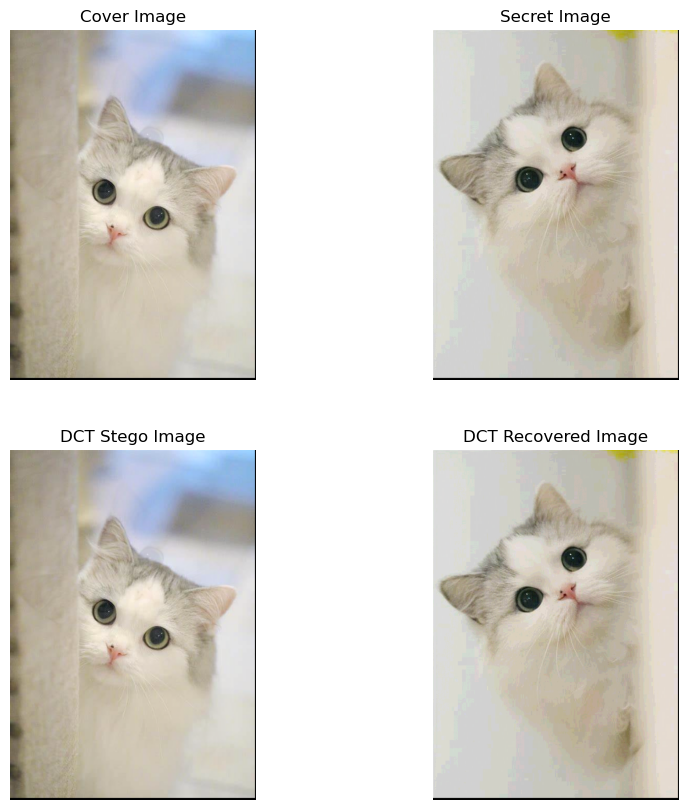

In [5]:
from scipy.fftpack import dct, idct

def apply_dct(img_block):
    # 离散余弦变换（DCT）
    return dct(dct(img_block.T, norm='ortho').T, norm='ortho')


def apply_idct(dct_block):
    # 逆离散余弦变换（IDCT）
    return idct(idct(dct_block.T, norm='ortho').T, norm='ortho')


def DCT_hide_image(cover_img, secret_img, alpha=0.1):
    stego_image = np.zeros_like(cover_img, dtype=np.float32)

    # 对 cover_img 和 secret_img 进行 DCT 变换
    for i in range(cover_img.shape[0] // 8):
        for j in range(cover_img.shape[1] // 8):
            # 提取8x8子块
            block_cover = cover_img[i * 8:(i + 1) * 8, j * 8:(j + 1) * 8]
            block_secret = secret_img[i * 8:(i + 1) * 8, j * 8:(j + 1) * 8]

            dct_block_cover = apply_dct(block_cover)
            dct_block_secret = apply_dct(block_secret)

            # 扩大嵌入系数的范围至全部，防止隐藏信息过少
            # 按比例叠加
            dct_block_cover[:, :] += alpha * dct_block_secret[:, :]
            stego_image[i * 8:(i + 1) * 8, j * 8:(j + 1) * 8] = apply_idct(dct_block_cover)

    return np.uint8(np.clip(stego_image, 0, 255))


def DCT_extract_image(stego_image, cover_img, alpha=0.1):
    recovered_image = np.zeros_like(cover_img, dtype=np.float32)

    # 对 cover_img 和 secret_img 进行 DCT 变换
    # 分割为8x8子块
    for i in range(cover_img.shape[0] // 8):
        for j in range(cover_img.shape[1] // 8):
            block_cover = cover_img[i * 8:(i + 1) * 8, j * 8:(j + 1) * 8]
            block_stego = stego_image[i * 8:(i + 1) * 8, j * 8:(j + 1) * 8]

            dct_block_cover = apply_dct(block_cover)
            dct_block_stego = apply_dct(block_stego)

            # 还原
            recovered_dct_block = (dct_block_stego - dct_block_cover) / alpha
            recovered_image[i * 8:(i + 1) * 8, j * 8:(j + 1) * 8] = apply_idct(recovered_dct_block)

    return np.uint8(np.clip(recovered_image, 0, 255))


def show_images(cover_img, secret_img, stego_img, recovered_img):
    # 转换为RGB
    cover_img = cv.cvtColor(cover_img, cv.COLOR_BGR2RGB)
    secret_img = cv.cvtColor(secret_img, cv.COLOR_BGR2RGB)
    stego_img = cv.cvtColor(stego_img, cv.COLOR_BGR2RGB)
    recovered_img = cv.cvtColor(recovered_img, cv.COLOR_BGR2RGB)

    # 显示图像
    plt.figure(figsize=(10, 10))
    plt.subplot(2, 2, 1)
    plt.title("Cover Image")
    plt.imshow(cover_img)
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.title("Secret Image")
    plt.imshow(secret_img)
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.title("DCT Stego Image")
    plt.imshow(stego_img)
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.title("DCT Recovered Image")
    plt.imshow(recovered_img)
    plt.axis('off')

    plt.show()


# 读取图像
cover_img = cv.imread('Q7_cover.jpg', cv.IMREAD_COLOR)
secret_img = cv.imread('Q7_secret.jpg', cv.IMREAD_COLOR)
x, y, z = secret_img.shape
cover_img = cover_img[:x, :y, :]

# 将图像转换为浮点数
cover_img = cover_img.astype(np.float32)
secret_img = secret_img.astype(np.float32)

# 嵌入水印
stego_image = DCT_hide_image(cover_img, secret_img, alpha=0.1)

# 从嵌入图像中提取水印
recovered_img = DCT_extract_image(stego_image, cover_img, alpha=0.1)

# 保存结果
cv.imwrite('Q7_DCT_stego.jpg', stego_image)
cv.imwrite('Q7_DCT_secret.jpg', recovered_img)

# 显示结果
cover_img = cv.imread('Q7_DCT_stego.jpg', cv.IMREAD_COLOR)
secret_img = cv.imread('Q7_DCT_secret.jpg', cv.IMREAD_COLOR)
show_images(cover_img, secret_img, stego_image, recovered_img)


## Q7-3 DWT方法

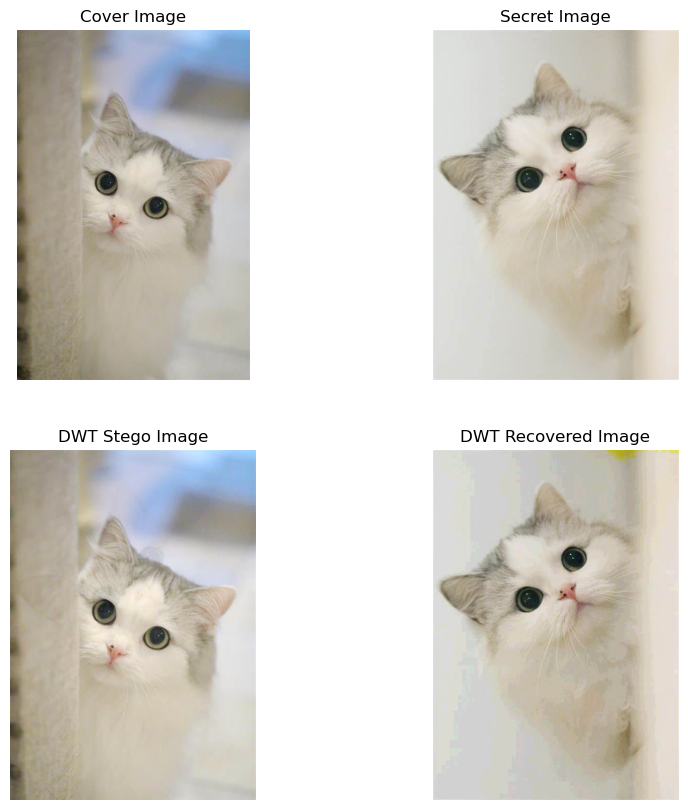

In [6]:
import pywt  # 用于小波变换的库

def dwt2(img):
    # 二维小波变换
    coeffs = pywt.dwt2(img, 'haar')
    return coeffs


def idwt2(coeffs):
    # 逆二维小波变换
    return pywt.idwt2(coeffs, 'haar')


def DWT_hide_image(cover_img, secret_img, alpha=0.1, beta=0.01):
    # DWT 变换
    cover_coeffs = dwt2(cover_img)
    secret_coeffs = dwt2(secret_img)

    # 提取 LL, (LH, HL, HH) 子带
    # 高频子带的微小变化对视觉影响不大，适合隐藏信息
    LL_cover, (LH_cover, HL_cover, HH_cover) = cover_coeffs
    LL_secret, (LH_secret, HL_secret, HH_secret) = secret_coeffs

    # 在cover的高频分量中嵌入secret的高频分量
    LL_stego = LL_cover + beta * LL_secret
    LH_stego = LH_cover + alpha * LH_secret
    HL_stego = HL_cover + alpha * HL_secret
    HH_stego = HH_cover + alpha * HH_secret

    # 重新组合
    stego_coeffs = (LL_stego, (LH_stego, HL_stego, HH_stego))
    stego_image = idwt2(stego_coeffs)

    return np.uint8(np.clip(stego_image, 0, 255))


def DWT_extract_image(stego_image, cover_img, alpha=0.1, beta=0.01):
    # DWT 变换
    stego_coeffs = dwt2(stego_image)
    cover_coeffs = dwt2(cover_img)

    # 提取 LL, (LH, HL, HH) 子带
    LL_cover, (LH_cover, HL_cover, HH_cover) = cover_coeffs
    LL_stego, (LH_stego, HL_stego, HH_stego) = stego_coeffs

    # 提取嵌入的secret的高频分量
    LL_secret = (LL_stego - LL_cover) / beta
    LH_secret = (LH_stego - LH_cover) / alpha
    HL_secret = (HL_stego - HL_cover) / alpha
    HH_secret = (HH_stego - HH_cover) / alpha

    # 重构秘密图像
    secret_coeffs = (LL_secret, (LH_secret, HL_secret, HH_secret))
    recovered_image = idwt2(secret_coeffs)

    return np.uint8(np.clip(recovered_image, 0, 255))


def show_images(cover_img, secret_img, stego_img, recovered_img):
    # 转换为RGB
    cover_img = cv.cvtColor(cover_img, cv.COLOR_BGR2RGB)
    secret_img = cv.cvtColor(secret_img, cv.COLOR_BGR2RGB)
    stego_img = cv.cvtColor(stego_img, cv.COLOR_BGR2RGB)
    recovered_img = cv.cvtColor(recovered_img, cv.COLOR_BGR2RGB)

    # 显示图像
    plt.figure(figsize=(10, 10))
    plt.subplot(2, 2, 1)
    plt.title("Cover Image")
    plt.imshow(cover_img)
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.title("Secret Image")
    plt.imshow(secret_img)
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.title("DWT Stego Image")
    plt.imshow(stego_img)
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.title("DWT Recovered Image")
    plt.imshow(recovered_img)
    plt.axis('off')

    plt.show()


# 读取图像
cover_img = cv.imread('Q7_cover.jpg')
secret_img = cv.imread('Q7_secret.jpg')

# 确保载体图像和秘密图像大小相同
x, y, z = secret_img.shape
cover_img = cover_img[:x, :y, :]

# 将图像转换为浮点数
cover_img = cover_img.astype(np.float32)
secret_img = secret_img.astype(np.float32)

# 使用 DWT 隐藏秘密图像
stego_image = DWT_hide_image(cover_img, secret_img, alpha=0.1, beta=0.1)

# 从加密的载体图像中提取秘密图像
recovered_img = DWT_extract_image(stego_image, cover_img, alpha=0.1, beta=0.1)

# 保存结果
cv.imwrite('Q7_DWT_stego.jpg', stego_image)
cv.imwrite('Q7_DWT_recovered.jpg', recovered_img)

# 显示结果
cover_img = cv.imread('Q7_cover.jpg')
secret_img = cv.imread('Q7_secret.jpg')
show_images(cover_img, secret_img, stego_image, recovered_img)
